In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [1]:
!git init


Initialized empty Git repository in C:/Users/BLAST/Desktop/A python class/Data Science Note/.git/


In [1]:
!git add

'git' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!git add

Nothing specified, nothing added.
hint: Maybe you wanted to say 'git add .'?
hint: Disable this message with "git config set advice.addEmptyPathspec false"


!git init


In [3]:
!git add .

In [4]:
!git status

On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .ipynb_checkpoints/An Introduction to Data Analysis (1)-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Array Manipulation-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Bootstrap Aggregation-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Categorical-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Class1_DataViz_Matplotlib-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Class2_Advanced_Full matplotlib-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Class2_Advanced_Full matpltlib3-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Hierarchical_Indexing_in_Pandas-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Increment and Decrement Operators-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Machine Learning - Confusion Matrix-checkpoint.ipynb
	new file:   .ipynb_checkpoints/Machine Learning - Regression-checkpoint.ipynb
	new file:   .ipynb_checkpoints/NUMPY_INCR_

In [5]:
git remote add origin https://github.com/Shalom-Ezeilo/AMR-under-One-Health.git

SyntaxError: invalid syntax (3583975160.py, line 1)

In [2]:
np.random.seed(42)
n_samples = 1000

df = pd.DataFrame({
    "year": np.random.choice([2021, 2022, 2023, 2024, 2025], n_samples),
    "state": np.random.choice(["Anambra", "Enugu", "Rivers", "Lagos"], n_samples),
    "source": np.random.choice(["Human", "Animal", "Food", "Environment"], n_samples),
    "organism": np.random.choice (["E. coli", "Klebsiella pneumoniae", "Staphylococcus aureus"],  n_samples ),
    "antibiotic": np.random.choice (["Ciprofloxacin", "Gentamicin", "Tetracycline", "Amoxicillin"], n_samples ),
    "age": np.random.randint(1, 80, n_samples),
    "zone_mm": np.random.randint(5, 45, n_samples),
    "result": np.random.choice(["S", "I", "R"], n_samples)})

df.head()

,year,state,source,organism,antibiotic,age,zone_mm,result
0,2024,Lagos,Food,Staphylococcus aureus,Gentamicin,68,15,R
1,2025,Lagos,Environment,E. coli,Ciprofloxacin,18,9,R
2,2023,Lagos,Human,E. coli,Tetracycline,43,41,I
3,2025,Lagos,Environment,Staphylococcus aureus,Amoxicillin,35,42,R
4,2025,Lagos,Food,Staphylococcus aureus,Gentamicin,78,33,I


Automatically create a messy data from the above

In [3]:
# Missing values
for col in ["state", "organism", "result"]:
    index = np.random.choice(df.index, 50, replace=False)
    df.loc[index, col] = np.nan

# Lowercase states
index = np.random.choice(df.index, 100, replace=False)
df.loc[index, "state"] = df.loc[index, "state"].str.lower()

# Make age flexible
df["age"] = df["age"].astype("object")

index = np.random.choice(df.index, 20, replace=False)
df.loc[index, "age"] = np.random.choice( [-5, 150, 200], 20)

# Make zone flexible
df["zone_mm"] = df["zone_mm"].astype("object")

index = np.random.choice(df.index, 20, replace=False)
df.loc[index, "zone_mm"] = np.random.choice( [-5, 70, 100], 20)

# Add duplicate records
duplicates = df.sample(20, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

# Save
df.to_csv("messy_AMR_data.csv", index=False)

print("Messy dataset created!")
print(df.shape)

Messy dataset created!
(1020, 8)


In [4]:
#inspect the data set
df.shape



(1020, 8)

In [5]:
df.columns

Index(['year', 'state', 'source', 'organism', 'antibiotic', 'age', 'zone_mm',
       'result'],
      dtype='str')

In [6]:
df.dtypes

year           int64
state            str
source           str
organism         str
antibiotic       str
age           object
zone_mm       object
result           str
dtype: object

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        1020 non-null   int64 
 1   state       968 non-null    str   
 2   source      1020 non-null   str   
 3   organism    969 non-null    str   
 4   antibiotic  1020 non-null   str   
 5   age         1020 non-null   object
 6   zone_mm     1020 non-null   object
 7   result      969 non-null    str   
dtypes: int64(1), object(2), str(5)
memory usage: 63.9+ KB


In [8]:
df.describe(include="all")


,year,state,source,organism,antibiotic,age,zone_mm,result
count,1020.000000,968,1020,969,1020,1020.0,1020.0,969
unique,NaN,8,4,3,4,82.0,43.0,3
top,NaN,Anambra,Human,E. coli,Ciprofloxacin,62.0,27.0,I
freq,NaN,235,269,331,272,23.0,33.0,354
mean,2023.001961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.431455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2023.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2024.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
#check for missing values
df.isnull().sum()




year           0
state         52
source         0
organism      51
antibiotic     0
age            0
zone_mm        0
result        51
dtype: int64

In [10]:
(df.isnull().sum() / len(df) * 100).round(2)

year          0.0
state         5.1
source        0.0
organism      5.0
antibiotic    0.0
age           0.0
zone_mm       0.0
result        5.0
dtype: float64

In [11]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)})

print(missing)

            Missing  Percentage
year              0         0.0
state            52         5.1
source            0         0.0
organism         51         5.0
antibiotic        0         0.0
age               0         0.0
zone_mm           0         0.0
result           51         5.0


In [12]:
#check for duplicates
df.duplicated().sum()

np.int64(20)

In [13]:
#Remove duplicate records
df = df.drop_duplicates()


In [14]:
#check duplicates again
df.duplicated().sum()

np.int64(0)

In [15]:
#Remove extra spaces and standardize capitalization.
text_columns = ["state", "source", "organism", "antibiotic", "result"]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()
# Standardize state and source
df["state"] = df["state"].str.strip().str.title()
df["source"] = df["source"].str.strip().str.title()

# Standardize organism names
df["organism"] = df["organism"].str.strip()

df["organism"] = df["organism"].replace({
    "e. coli": "E. coli",
    "E. Coli": "E. coli",
    "E. coli": "E. coli",
    "klebsiella pneumoniae": "Klebsiella pneumoniae",
    "Klebsiella Pneumoniae": "Klebsiella pneumoniae",
    "staphylococcus aureus": "Staphylococcus aureus",
    "Staphylococcus Aureus": "Staphylococcus aureus"
})

# Standardize antibiotic names
df["antibiotic"] = df["antibiotic"].str.strip().str.title()

# Standardize AMR result
df["result"] = df["result"].str.strip().str.upper()


In [16]:
#Standardize organism names
df["organism"] = df["organism"].str.strip()
df["organism"].value_counts(dropna=False)

organism
E. coli                  325
Staphylococcus aureus    314
Klebsiella pneumoniae    311
<NA>                      50
Name: count, dtype: Int64

In [29]:
#fix invalid age
df["age"] = pd.to_numeric( df["age"],errors="coerce")
df.loc[  (df["age"] < 1) | (df["age"] > 100), "age"]
df.loc[ (df["age"] < 1) | (df["age"] > 100), "age"] = np.nan

df["age"].describe()

count    1000.000000
mean       40.811000
std        22.312039
min         1.000000
25%        22.000000
50%        41.000000
75%        59.250000
max        79.000000
Name: age, dtype: float64

In [30]:
# Create age groups
df["age_group"] = pd.cut( df["age"], bins=[0, 4, 14, 24, 44, 64, 100],
    labels=["0–4", "5–14", "15–24", "25–44", "45–64", "65–100" ])


In [31]:

df["age"].isnull().sum()

np.int64(0)

In [32]:
df["age"] = df["age"].fillna( df["age"].median())


In [20]:
df["age"].isnull().sum()

np.int64(0)

In [21]:
#Fix zone_mm

df["zone_mm"] = pd.to_numeric( df["zone_mm"], errors="coerce")
#Check invalid values:
df.loc[(df["zone_mm"] < 0) | (df["zone_mm"] > 60), "zone_mm"]
df.loc[ (df["zone_mm"] < 0) | (df["zone_mm"] > 60), "zone_mm"] = np.nan
df["zone_mm"].isnull().sum()

    

np.int64(20)

In [22]:
# handle missing zone
df["zone_mm"] = df["zone_mm"].fillna( df["zone_mm"].median())

df["zone_mm"].isnull().sum()


np.int64(0)

In [23]:
#handle missing categorical values
for col in ["state", "organism", "result"]:
    df[col] = df[col].fillna("Unknown")

df.isnull().sum()


year          0
state         0
source        0
organism      0
antibiotic    0
age           0
zone_mm       0
result        0
dtype: int64

In [24]:
# final cleaning check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        1000 non-null   int64  
 1   state       1000 non-null   string 
 2   source      1000 non-null   string 
 3   organism    1000 non-null   string 
 4   antibiotic  1000 non-null   string 
 5   age         1000 non-null   float64
 6   zone_mm     1000 non-null   float64
 7   result      1000 non-null   string 
dtypes: float64(2), int64(1), string(5)
memory usage: 62.6 KB


In [25]:
df.isnull().sum()

year          0
state         0
source        0
organism      0
antibiotic    0
age           0
zone_mm       0
result        0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.head(10)

,year,state,source,organism,antibiotic,age,zone_mm,result,age_group
0,2024,Lagos,Food,Unknown,Gentamicin,68.0,15.0,R,65–100
1,2025,Lagos,Environment,E. coli,Ciprofloxacin,18.0,9.0,R,15–24
2,2023,Lagos,Human,E. coli,Tetracycline,43.0,41.0,I,25–44
3,2025,Lagos,Environment,Staphylococcus aureus,Amoxicillin,35.0,42.0,R,25–44
4,2025,Lagos,Food,Staphylococcus aureus,Gentamicin,78.0,33.0,I,65–100
5,2022,Anambra,Human,E. coli,Ciprofloxacin,41.0,9.0,S,25–44
6,2023,Lagos,Food,E. coli,Gentamicin,33.0,13.0,R,25–44
7,2023,Anambra,Food,E. coli,Tetracycline,14.0,6.0,S,5–14
8,2023,Lagos,Animal,Klebsiella pneumoniae,Tetracycline,34.0,24.0,R,25–44
9,2025,Rivers,Human,Staphylococcus aureus,Amoxicillin,61.0,44.0,R,45–64


In [34]:
df.sample(10, random_state=42)

,year,state,source,organism,antibiotic,age,zone_mm,result,age_group
521,2021,Anambra,Environment,Staphylococcus aureus,Ciprofloxacin,21.0,32.0,S,15–24
737,2024,Enugu,Environment,Klebsiella pneumoniae,Tetracycline,40.0,8.0,R,25–44
740,2022,Enugu,Animal,E. coli,Tetracycline,60.0,12.0,S,45–64
660,2025,Rivers,Human,E. coli,Tetracycline,43.0,23.0,I,25–44
411,2022,Lagos,Environment,Klebsiella pneumoniae,Gentamicin,57.0,38.0,R,45–64
678,2025,Anambra,Human,Klebsiella pneumoniae,Ciprofloxacin,73.0,19.0,I,65–100
626,2024,Lagos,Human,E. coli,Ciprofloxacin,4.0,18.0,S,0–4
513,2024,Lagos,Human,Unknown,Tetracycline,33.0,43.0,I,25–44
859,2023,Lagos,Human,Klebsiella pneumoniae,Ciprofloxacin,15.0,31.0,R,15–24
136,2024,Enugu,Food,Klebsiella pneumoniae,Ciprofloxacin,53.0,10.0,Unknown,45–64


Basic Descriptive analysis

In [35]:
# Number of records by year
df["year"].value_counts().sort_index()

year
2021    210
2022    190
2023    190
2024    206
2025    204
Name: count, dtype: int64

In [36]:
#Records by state
df["state"].value_counts()


state
Anambra    255
Enugu      240
Rivers     234
Lagos      221
Unknown     50
Name: count, dtype: Int64

In [37]:
#Records by source
df["source"].value_counts()


source
Human          260
Animal         259
Environment    252
Food           229
Name: count, dtype: Int64

In [40]:
#Records by organism
df["organism"].value_counts()




organism
E. coli                  325
Staphylococcus aureus    314
Klebsiella pneumoniae    311
Unknown                   50
Name: count, dtype: Int64

In [41]:
#Records by antibiotic
df["antibiotic"].value_counts()



antibiotic
Ciprofloxacin    265
Amoxicillin      253
Tetracycline     248
Gentamicin       234
Name: count, dtype: Int64

In [42]:
#AMR results
df["result"].value_counts()

result
I          346
S          305
R          299
Unknown     50
Name: count, dtype: Int64

In [55]:
# Overall resistance prevalence
overall_resistance = df["resistant"].mean() * 100

print( f"Overall resistance: {overall_resistance:.2f}%")


Overall resistance: 29.90%


In [43]:
#Calculate resistance percentage

result_percent = ( df["result"]
    .value_counts(normalize=True)
    .mul(100) .round(2))

result_percent



result
I          34.6
S          30.5
R          29.9
Unknown     5.0
Name: proportion, dtype: Float64

In [44]:
# Calculate resistance by antibiotic

resistance_by_antibiotic = pd.crosstab( df["antibiotic"], df["result"],
    normalize="index") * 100

resistance_percentage = ( df.assign( resistant=df["result"].eq("R") )
    .groupby("antibiotic")["resistant"] .mean() .mul(100) .round(2))
resistance_percentage


antibiotic
Amoxicillin      30.83
Ciprofloxacin     28.3
Gentamicin       29.91
Tetracycline     30.65
Name: resistant, dtype: Float64

In [45]:
#Resistance by organism
resistance_by_organism = ( df.assign(  resistant=df["result"].eq("R"))
    .groupby("organism")["resistant"] .mean() .mul(100) .round(2))
resistance_by_organism


organism
E. coli                  27.69
Klebsiella pneumoniae    30.87
Staphylococcus aureus    31.53
Unknown                   28.0
Name: resistant, dtype: Float64

In [50]:
#resistance_by_state
resistance_by_state= (
    df.assign( resistant=df["result"].eq("R"))
    .groupby("state")["resistant"] .mean() .mul(100).round(2))

resistance_by_state


state
Anambra    32.16
Enugu      33.75
Lagos      28.05
Rivers     26.07
Unknown     26.0
Name: resistant, dtype: Float64

In [49]:
# Resistance by year
resistance_by_year = (df.assign( resistant=df["result"].eq("R") )
    .groupby("year")["resistant"] .mean().mul(100).round(2))
resistance_by_year

year
2021    27.14
2022    33.16
2023    32.63
2024    29.13
2025    27.94
Name: resistant, dtype: Float64

In [53]:
# Create a binary resistance variable

df["resistant"] = np.where( df["result"] == "R", 1, 0)

df[["result", "resistant"]].head()



,result,resistant
0,R,1
1,R,1
2,I,0
3,R,1
4,I,0


In [48]:
 # Cross-tabulation: organism vs antibiotic
organism_antibiotic = pd.crosstab( df["organism"], df["antibiotic"])

organism_antibiotic

antibiotic,Amoxicillin,Ciprofloxacin,Gentamicin,Tetracycline
organism,,,,
E. coli,82,90,65,88
Klebsiella pneumoniae,72,85,82,72
Staphylococcus aureus,91,82,70,71
Unknown,8,8,17,17


In [46]:
#Cross-tabulation: antibiotic vs result
antibiotic_result = pd.crosstab(df["antibiotic"], df["result"])
antibiotic_result


result,I,R,S,Unknown
antibiotic,,,,
Amoxicillin,83,78,75,17
Ciprofloxacin,95,75,87,8
Gentamicin,93,70,63,8
Tetracycline,75,76,80,17


In [51]:
#Resistance by age group
resistance_by_age = ( df.assign( resistant=df["result"].eq("R") )
    .groupby("age_group", observed=True)["resistant"]
    .mean() .mul(100) .round(2))

resistance_by_age


age_group
0–4       36.36
5–14      27.83
15–24      36.0
25–44     30.15
45–64      29.6
65–100    25.42
Name: resistant, dtype: Float64

In [57]:
# Advanced: resistance by antibiotic and year
resistance_year_antibiotic = (
    df.groupby(["year", "antibiotic"])["resistant"]
      .mean() .mul(100) .round(2) .reset_index())

resistance_year_antibiotic


,year,antibiotic,resistant
0,2021,Amoxicillin,30.36
1,2021,Ciprofloxacin,20.69
2,2021,Gentamicin,28.89
3,2021,Tetracycline,29.41
4,2022,Amoxicillin,36.00
5,2022,Ciprofloxacin,26.83
6,2022,Gentamicin,32.00
7,2022,Tetracycline,36.73
8,2023,Amoxicillin,22.92
9,2023,Ciprofloxacin,40.74


In [59]:
# Advanced: resistance by organism and antibiotic
organism_antibiotic_resistance = (
    df.groupby(  ["organism", "antibiotic"]
    )["resistant"]
    .mean() .mul(100).round(2).reset_index())

organism_antibiotic_resistance


,organism,antibiotic,resistant
0,E. coli,Amoxicillin,26.83
1,E. coli,Ciprofloxacin,28.89
2,E. coli,Gentamicin,27.69
3,E. coli,Tetracycline,27.27
4,Klebsiella pneumoniae,Amoxicillin,33.33
5,Klebsiella pneumoniae,Ciprofloxacin,28.24
6,Klebsiella pneumoniae,Gentamicin,31.71
7,Klebsiella pneumoniae,Tetracycline,30.56
8,Staphylococcus aureus,Amoxicillin,32.97
9,Staphylococcus aureus,Ciprofloxacin,25.61


In [60]:
# Create an AMR heatmap table
amr_heatmap = pd.pivot_table( df,
    values="resistant", index="organism",
    columns="antibiotic",aggfunc="mean") * 100

amr_heatmap.round(2)


antibiotic,Amoxicillin,Ciprofloxacin,Gentamicin,Tetracycline
organism,,,,
E. coli,26.83,28.89,27.69,27.27
Klebsiella pneumoniae,33.33,28.24,31.71,30.56
Staphylococcus aureus,32.97,25.61,28.57,39.44
Unknown,25.00,50.00,35.29,11.76


Text(0.5, 1.0, 'Number of AMR Records by Year')

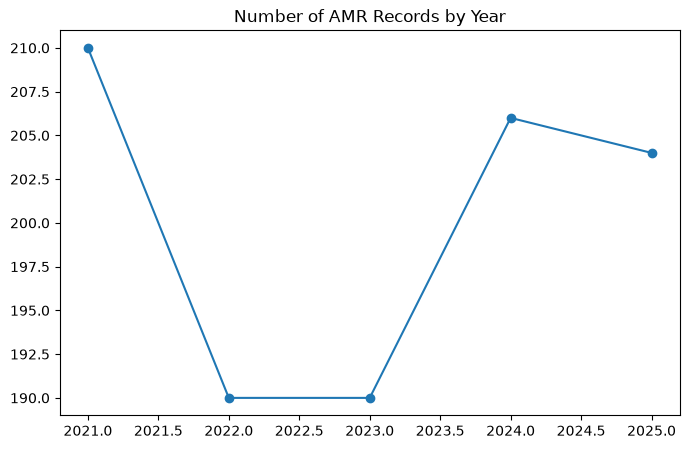

In [52]:
#Plot 1 — Number of records by year
year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.plot( year_counts.index, year_counts.values,marker="o")

plt.title("Number of AMR Records by Year")


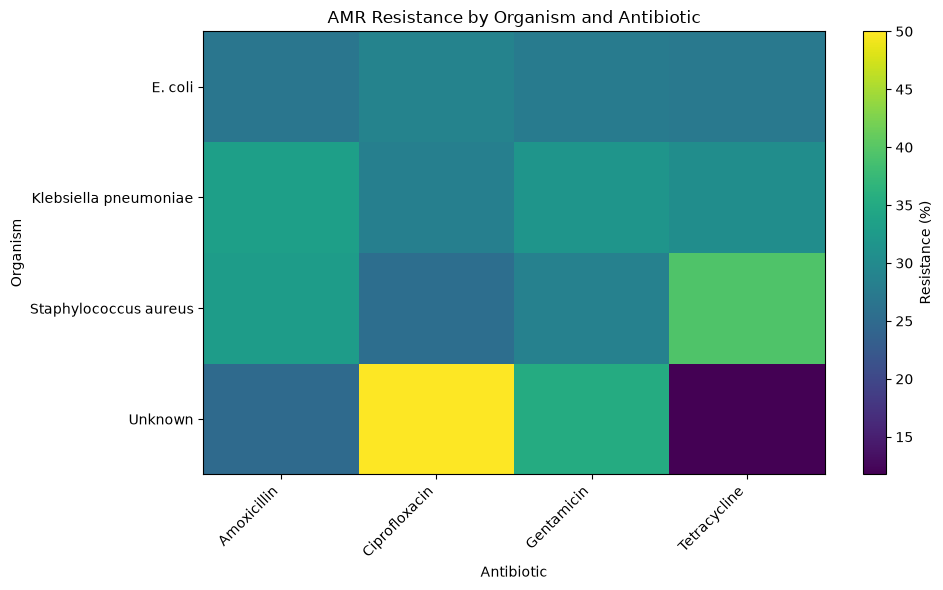

In [61]:
# Plot the AMR heatmap
plt.figure(figsize=(10, 6))

plt.imshow( amr_heatmap,aspect="auto")

plt.colorbar(label="Resistance (%)")

plt.xticks(
    range(len(amr_heatmap.columns)),
    amr_heatmap.columns, rotation=45, ha="right")

plt.yticks( range(len(amr_heatmap.index)), amr_heatmap.index)

plt.title("AMR Resistance by Organism and Antibiotic")
plt.xlabel("Antibiotic")
plt.ylabel("Organism")

plt.tight_layout()
plt.show()


In [71]:
## Create a contingency table
table = pd.crosstab(df["antibiotic"], df["result"])

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

# Display results
print("Chi-square:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

# Interpretation
if p < 0.05:
    print("There is a statistically significant association between antibiotic and result.")
else:
    print("There is no statistically significant association.")



Chi-square: 12.068947496289368
Degrees of freedom: 9
p-value: 0.20945023163422324
There is no statistically significant association.


In [73]:
#Create a binary table:
state_table = pd.crosstab( df["state"],
    df["resistant"])

chi2, p, dof, expected = chi2_contingency(
    state_table)

print("Chi-square:", chi2)
print("p-value:", p)


Chi-square: 4.677989928677303
p-value: 0.3219609186316704


In [74]:
# Advanced: 95% confidence interval

resistant_count = df["resistant"].sum()
total = len(df)

lower, upper = proportion_confint(
    resistant_count,total, alpha=0.05,
    method="wilson")

print( f"Resistance: {overall_resistance:.2f}%")

print( f"95% CI: {lower * 100:.2f}% – {upper * 100:.2f}%")


Resistance: 29.90%
95% CI: 27.14% – 32.81%


In [75]:
# 95% CI for each antibiotic
results = []

for antibiotic, group in df.groupby("antibiotic"):

    # Number of resistant isolates
    resistant = group["resistant"].sum()

    # Total number tested
    total = len(group)

    # Calculate 95% Wilson confidence interval
    lower, upper = proportion_confint( count=resistant, nobs=total, alpha=0.05,
        method="wilson" )

    # Store results
    results.append({ "antibiotic": antibiotic, "tested": total,
        "resistant": resistant, "resistance_percent": (resistant / total) * 100,
        "lower_ci": lower * 100, "upper_ci": upper * 100 })

# Convert results to DataFrame
antibiotic_ci = pd.DataFrame(results)

# Round percentages and CIs
antibiotic_ci[
    ["resistance_percent", "lower_ci", "upper_ci"]] = antibiotic_ci[
    ["resistance_percent", "lower_ci", "upper_ci"]].round(2)

# Display result
antibiotic_ci

,antibiotic,tested,resistant,resistance_percent,lower_ci,upper_ci
0,Amoxicillin,253,78,30.83,25.46,36.77
1,Ciprofloxacin,265,75,28.30,23.22,34.01
2,Gentamicin,234,70,29.91,24.41,36.07
3,Tetracycline,248,76,30.65,25.24,36.64


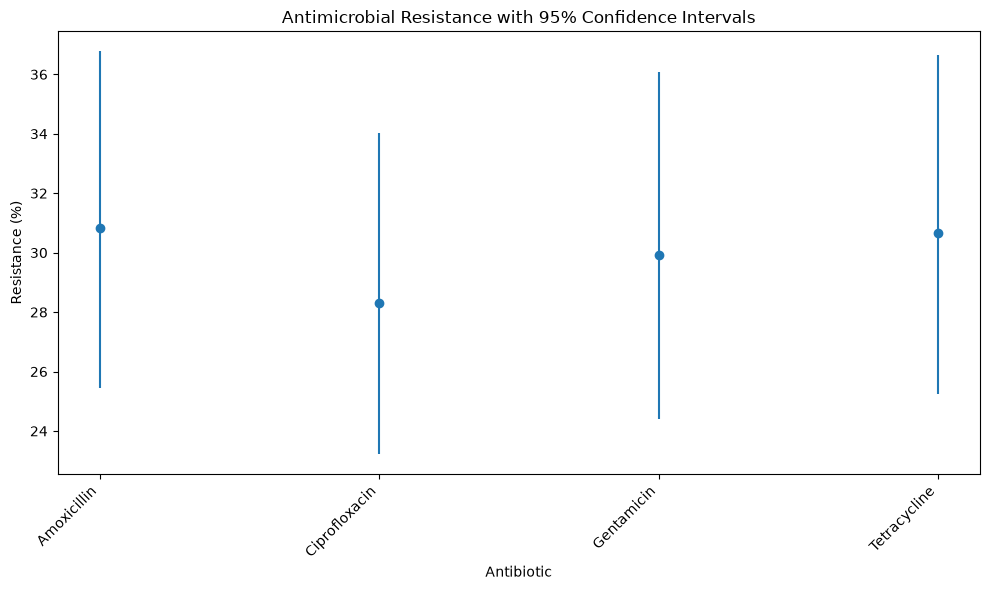

Graph exported successfully as AMR_resistance_95CI.png


In [92]:
 # Advanced visualization — resistance with confidence intervals
plt.figure(figsize=(10, 6))

x = np.arange(len(antibiotic_ci))

y = antibiotic_ci["resistance_percent"]

lower_error = ( y - antibiotic_ci["lower_ci"])

upper_error = ( antibiotic_ci["upper_ci"] - y)

plt.errorbar( x, y, yerr=[lower_error, upper_error],
    fmt="o")

plt.xticks(x, antibiotic_ci["antibiotic"], rotation=45,
    ha="right")

plt.ylabel("Resistance (%)")
plt.xlabel("Antibiotic")
plt.title("Antimicrobial Resistance with 95% Confidence Intervals")

plt.tight_layout()
# Export as high-resolution PNG
plt.savefig("AMR_resistance_95CI.png",
    dpi=300,bbox_inches="tight")

plt.show()

print("Graph exported successfully as AMR_resistance_95CI.png")


In [78]:
# Advanced: logistic regression


model = smf.logit(
    "resistant ~ age + C(state) + C(organism) + C(antibiotic) + C(source) + year",
    data=df).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.604723
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              resistant   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      984
Method:                           MLE   Df Model:                           15
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                0.008674
Time:                        17:31:53   Log-Likelihood:                -604.72
converged:                       True   LL-Null:                       -610.01
Covariance Type:            nonrobust   LLR p-value:                    0.7816
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                1.4170     98.3

In [80]:
# Convert logistic regression coefficients to odds ratios
odds_ratios = pd.DataFrame({ "Variable": model.params.index,
    "Odds_Ratio": np.exp(model.params.values), "P_value": model.pvalues.values})
odds_ratios



,Variable,Odds_Ratio,P_value
0,Intercept,4.124861,0.988506
1,C(state)[T.Enugu],1.091507,0.650543
2,C(state)[T.Lagos],0.826961,0.348520
3,C(state)[T.Rivers],0.746579,0.147339
4,C(state)[T.Unknown],0.767572,0.453955
5,C(organism)[T.Klebsiella pneumoniae],1.165945,0.383038
6,C(organism)[T.Staphylococcus aureus],1.197834,0.303660
7,C(organism)[T.Unknown],0.976487,0.944586
8,C(antibiotic)[T.Ciprofloxacin],0.870223,0.475303
9,C(antibiotic)[T.Gentamicin],0.949488,0.795450


In [82]:
# Create resistance_year
resistance_year = (
    df.groupby("year")["resistant"]
    .agg(["sum", "count"]).rename(columns={  "sum": "resistant",
        "count": "tested" }))

resistance_year["resistance_percent"] = ( resistance_year["resistant"] /
    resistance_year["tested"] * 100)

resistance_year

,resistant,tested,resistance_percent
year,,,
2021,57,210,27.142857
2022,63,190,33.157895
2023,62,190,32.631579
2024,60,206,29.126214
2025,57,204,27.941176


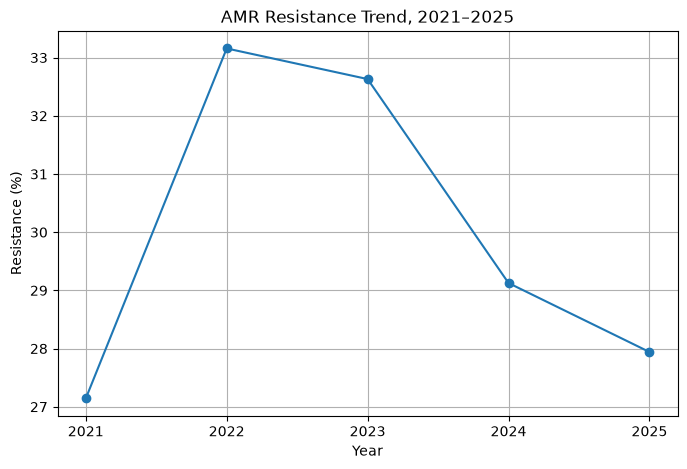

Graph exported successfully as AMR_resistance_year.png


In [93]:
# Plot resistance trend
plt.figure(figsize=(8, 5))

plt.plot( resistance_year.index,
    resistance_year["resistance_percent"],
    marker="o")

plt.xlabel("Year")
plt.ylabel("Resistance (%)")
plt.title("AMR Resistance Trend, 2021–2025")
plt.xticks(resistance_year.index)
plt.grid(True)

# Export as high-resolution PNG
plt.savefig("AMR_resistance_year.png",
    dpi=300,bbox_inches="tight")

plt.show()

print("Graph exported successfully as AMR_resistance_year.png")


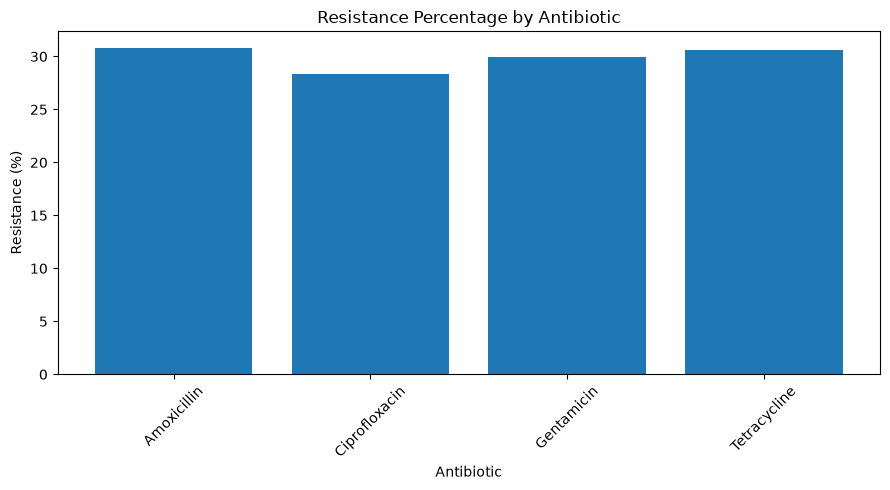

Graph exported successfully as AMR_resistance_antibiotics.png


In [94]:
# Plot resistance by antibiotic
plt.figure(figsize=(9, 5))

plt.bar( antibiotic_ci["antibiotic"],
    antibiotic_ci["resistance_percent"])

plt.xlabel("Antibiotic")
plt.ylabel("Resistance (%)")
plt.title("Resistance Percentage by Antibiotic")

plt.xticks(rotation=45)

plt.tight_layout()
# Export as high-resolution PNG
plt.savefig("AMR_resistance_antibiotics.png", dpi=300,bbox_inches="tight")

plt.show()

print("Graph exported successfully as AMR_resistance_antibiotics.png")


In [86]:
# create resistance_organism
resistance_organism = ( df.groupby("organism")["resistant"]
    .agg(["sum", "count"]) .rename(columns={
        "sum": "resistant","count": "tested"}))

resistance_organism["resistance_percent"] = (
    resistance_organism["resistant"] /
    resistance_organism["tested"] * 100)

# Round percentage
resistance_organism["resistance_percent"] = (
    resistance_organism["resistance_percent"].round(2))

resistance_organism

,resistant,tested,resistance_percent
organism,,,
E. coli,90,325,27.69
Klebsiella pneumoniae,96,311,30.87
Staphylococcus aureus,99,314,31.53
Unknown,14,50,28.00


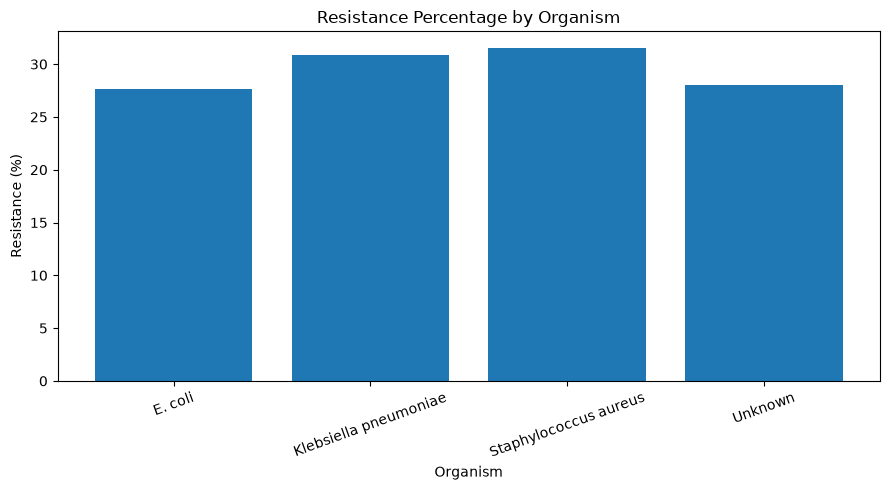

Graph exported successfully as AMR_resistance_Organism.png


In [95]:
# Plot resistance by organism
plt.figure(figsize=(9, 5))

plt.bar( resistance_organism.index,
    resistance_organism["resistance_percent"])

plt.xlabel("Organism")
plt.ylabel("Resistance (%)")
plt.title("Resistance Percentage by Organism")

plt.xticks(rotation=20)

plt.tight_layout()
# Export as high-resolution PNG
plt.savefig("AMR_resistance_Organism.png",
    dpi=300,bbox_inches="tight")

plt.show()

print("Graph exported successfully as AMR_resistance_Organism.png")


In [88]:
# Create an analysis summary table
summary = pd.DataFrame({
    "Indicator": [ "Total records",
        "Total resistant records",
        "Overall resistance (%)",
        "Number of states",
        "Number of organisms",
        "Number of antibiotics" ],
    "Value": [ len(df),
        df["resistant"].sum(),
        round(df["resistant"].mean() * 100, 2),
        df["state"].nunique(),
        df["organism"].nunique(),
        df["antibiotic"].nunique() ]})

summary



,Indicator,Value
0,Total records,1000.0
1,Total resistant records,299.0
2,Overall resistance (%),29.9
3,Number of states,5.0
4,Number of organisms,4.0
5,Number of antibiotics,4.0


In [96]:
# Export your advanced results
# Export the cleaned dataset:

df.to_csv(  "clean_AMR_data.csv", index=False)

# Export antibiotic resistance:
antibiotic_ci.to_csv( "AMR_resistance_by_antibiotic.csv",index=False)

 # Export organism resistance:

resistance_organism.to_csv( "AMR_resistance_by_organism.csv")

# Export yearly resistance:

resistance_year.to_csv( "AMR_resistance_by_year.csv")
